Suppose a company claims that the average delivery time is 30 minutes.
We (data scientists) want to test if deliveries are actually slower than claimed.
We have:

Population standard deviation (
𝜎
σ) = 4 minutes (known from past records).

We collect a sample of delivery times from 50 orders.

***

## Generate dataset

In [1]:
import numpy as np
import pandas as pd

In [2]:
np.random.seed(42)

In [11]:
# Population parameters
mu = 30       # claimed population mean
sigma = 4     # known population std dev
n = 50        # sample size

# Generate sample data (simulate slightly slower deliveries)
sample_data = np.random.normal(loc=31, scale=sigma, size=n)

# Put into DataFrame
df = pd.DataFrame(sample_data, columns=["delivery_time"])
df.head()

,delivery_time
0,32.296336
1,29.459671
2,28.292312
3,33.446705
4,35.123998


In [12]:
from scipy.stats import norm
import statsmodels.stats.weightstats as sw


Perform One sample z test using stats model


In [ ]:
z_stat,p_value=sw.ztest(df['delivery_time'],value=mu,alternative='larger')

In [13]:
print('sample mean: ',round(df['delivery_time'].mean(),2))
print('Z test: ',round(z_stat,3))
print('p value: ',round(p_value,4))





sample mean:  31.07
Z test:  0.186
p value:  0.4263


making decision

In [15]:
alpha = 0.05
z_crit = norm.ppf(1-alpha)
z_crit

1.6448536269514722

In [16]:
if z_stat > z_crit:
    decision = "Reject H0: Deliveries are significantly slower."
else:
    decision = "Fail to reject H0: No evidence deliveries are slower."

In [17]:
decision

'Fail to reject H0: No evidence deliveries are slower.'

In [21]:
if p_value < alpha:
    decision2 = "Reject H0: Deliveries are significantly slower."
else:
    decision2 = "Fail to reject H0: No evidence deliveries are slower."

In [22]:
decision2

'Fail to reject H0: No evidence deliveries are slower.'

In [23]:
sample_mean = df["delivery_time"].mean()    # Mean of sample data
SE = sigma / np.sqrt(n)                     # Standard Error of the mean

z_crit = norm.ppf(1 - alpha)                # Critical z-value for one-tailed test (right-tailed)

# Confidence interval formula (two-sided)
CI_lower = sample_mean - z_crit * SE
CI_upper = sample_mean + z_crit * SE

print(f"{(1-alpha)*100:.1f}% Confidence Interval: ({CI_lower:.2f}, {CI_upper:.2f})")

95.0% Confidence Interval: (30.14, 32.00)


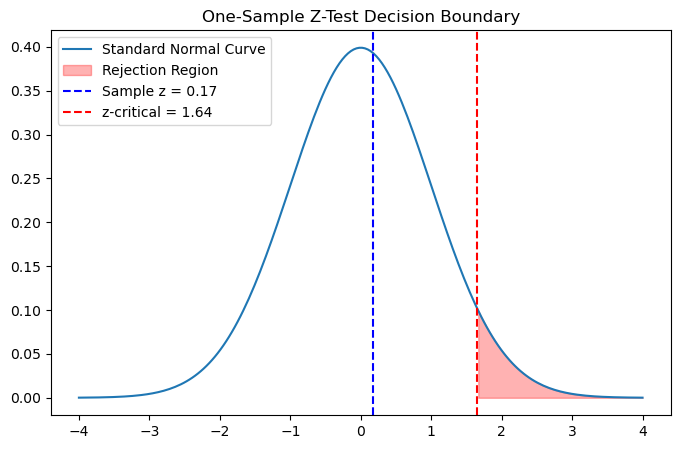

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Critical z at alpha = 0.05 (right-tailed)
alpha = 0.05
z_crit = norm.ppf(1 - alpha)

# Plot normal curve
x = np.linspace(-4, 4, 200)
y = norm.pdf(x)

plt.figure(figsize=(8,5))
plt.plot(x, y, label="Standard Normal Curve")

# Shade rejection region
plt.fill_between(x, 0, y, where=(x > z_crit), color="red", alpha=0.3, label="Rejection Region")

# Mark z value
plt.axvline(z, color="blue", linestyle="--", label=f"Sample z = {z:.2f}")
plt.axvline(z_crit, color="red", linestyle="--", label=f"z-critical = {z_crit:.2f}")

plt.title("One-Sample Z-Test Decision Boundary")
plt.legend()
plt.show()
